# Emotion Classification from Text — Machine Learning Assignment

## Student Details
- **Name:** [שם פרטי + אות ראשונה של שם משפחה]
- **ID (last 4 digits):** [4 ספרות]

## Problem Description
This assignment addresses a **multi-class text classification** problem: given a short
English sentence describing a personal experience, predict the emotion it expresses.

The dataset contains 20,000 English sentences collected from Twitter, labeled with one
of six emotions: *joy*, *sadness*, *anger*, *fear*, *love*, and *surprise*. It arrives
pre-split into 16,000 training examples, 2,000 test examples and 2,000 validation examples.

The dataset is notably **imbalanced** — the largest class (*joy*, 5,362 examples) is
roughly 9 times larger than the smallest (*surprise*, 572 examples). This imbalance
drives several decisions made later in this notebook.

**Learning type:** Supervised classification
**Algorithm:** Multinomial Naive Bayes (implemented from scratch)
**Evaluation metric:** Macro-averaged F1

**Dataset:** https://www.kaggle.com/datasets/praveengovi/emotions-dataset-for-nlp

## AI Assistance
See the dedicated cell below documenting all AI chatbot usage.

## AI Assistance — Prompts and Usage

This section documents all use of AI chatbots during this assignment, as required.

**Tool used:** Claude (Anthropic)

| # | Purpose | Prompt / Question | How the output was used |
|---|---------|-------------------|-------------------------|
| 1 | Choosing an algorithm | Asked whether Naive Bayes is a suitable algorithm for this dataset and assignment requirements | Confirmed the choice; guided the decision to use macro-F1 and to treat class imbalance as an extension |
| 2 | Data loading | Asked how to load a semicolon-separated text file without a header row into pandas | Learned about the `sep`, `names` and `header` parameters of `read_csv` |
| 3 | Data validation | Asked what sanity checks should be run on a text dataset before modeling | Added checks for missing values, duplicate rows, and train/test overlap |

*(Rows will be added as work progresses.)*

---
# Part 1 — Data Loading and Exploration

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option('display.max_colwidth', 200)


def load_data(file_path):
    """Load a semicolon-separated emotion dataset file into a DataFrame."""
    return pd.read_csv(file_path, sep=';', names=['text', 'label'], header=None)


def print_data_info(data, name):
    """Print shape, missing values, duplicates, class distribution and first rows."""
    print(f"--- {name} ---")
    print("Shape:", data.shape)

    print("\nMissing values per column:")
    print(data.isnull().sum())

    print("\nExact duplicate rows (text + label):", data.duplicated().sum())
    print("Duplicate texts (regardless of label):", data.duplicated(subset='text').sum())

    print("\nClass distribution:")
    print(data['label'].value_counts())

    print("\nFirst 5 rows:")
    display(data.head())
    print()


train = load_data('data/train.txt')
test = load_data('data/test.txt')
val = load_data('data/val.txt')

print_data_info(train, "Train")
print_data_info(test, "Test")
print_data_info(val, "Validation")

--- Train ---
Shape: (16000, 2)

Missing values per column:
text     0
label    0
dtype: int64

Exact duplicate rows (text + label): 1
Duplicate texts (regardless of label): 31

Class distribution:
label
joy         5362
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572
Name: count, dtype: int64

First 5 rows:


,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplace i will know that it is still on the property,love
4,i am feeling grouchy,anger



--- Test ---
Shape: (2000, 2)

Missing values per column:
text     0
label    0
dtype: int64

Exact duplicate rows (text + label): 0
Duplicate texts (regardless of label): 0

Class distribution:
label
joy         695
sadness     581
anger       275
fear        224
love        159
surprise     66
Name: count, dtype: int64

First 5 rows:


,text,label
0,im feeling rather rotten so im not very ambitious right now,sadness
1,im updating my blog because i feel shitty,sadness
2,i never make her separate from me because i don t ever want her to feel like i m ashamed with her,sadness
3,i left with my bouquet of red and yellow tulips under my arm feeling slightly more optimistic than when i arrived,joy
4,i was feeling a little vain when i did this one,sadness



--- Validation ---
Shape: (2000, 2)

Missing values per column:
text     0
label    0
dtype: int64

Exact duplicate rows (text + label): 0
Duplicate texts (regardless of label): 2

Class distribution:
label
joy         704
sadness     550
anger       275
fear        212
love        178
surprise     81
Name: count, dtype: int64

First 5 rows:


,text,label
0,im feeling quite sad and sorry for myself but ill snap out of it soon,sadness
1,i feel like i am still looking at a blank canvas blank pieces of paper,sadness
2,i feel like a faithful servant,love
3,i am just feeling cranky and blue,anger
4,i can have for a treat or if i am feeling festive,joy


### Data Quality Findings

**Missing values:** None in any split.

**Duplicates in the training set:** One exact duplicate row (identical text *and* label).
More interestingly, 31 texts appear more than once — meaning roughly 30 sentences carry
*conflicting labels* across their occurrences. The same sentence is annotated, for
example, as both *anger* and *sadness*.

These are annotation inconsistencies inherent to the dataset rather than errors in
loading. They set a small theoretical ceiling on achievable accuracy: no classifier can
be correct on both copies of a contradictory example.

**Decision: these rows are kept.** Removing both copies would discard genuine data, and
removing one copy would require arbitrarily deciding which label is correct. At roughly
0.2% of the training set the effect is negligible. The finding is documented here for
transparency.

**Test set:** Completely clean — no missing values and no duplicates of any kind. This
is important, since the test set is the basis for the final reported score.

### Checking for Overlap Between Splits

Before any modeling, we verify that no sentence appears in more than one split.
An example present in both the training and test sets would be seen by the model
during training and then used to evaluate it — a form of data leakage that inflates
the reported score.

In [2]:
train_texts = set(train['text'])
test_texts = set(test['text'])
val_texts = set(val['text'])

print("Overlap between train and test:", len(train_texts & test_texts))
print("Overlap between train and val: ", len(train_texts & val_texts))
print("Overlap between test and val:  ", len(test_texts & val_texts))

Overlap between train and test: 11
Overlap between train and val:  5
Overlap between test and val:   3


### Data Leakage Check

Eleven sentences appear in both the training set and the test set. If left in place,
the model would be evaluated on examples it had already seen during training, inflating
the reported score and misrepresenting how the model generalises to unseen data.

These eleven examples were removed **from the training set** rather than from the test
set: the test set is the fixed benchmark against which final performance is reported and
must not be modified. The removal costs 0.07% of the training data, which is negligible.

The five sentences shared between train and validation, and the three shared between test
and validation, require no action — the validation file is not used anywhere in this
notebook, as 5-fold cross-validation on the training set serves that role instead.

In [3]:
overlap = train_texts & test_texts
print(f"Removing {len(overlap)} training examples that also appear in the test set.")
print("Train size before:", train.shape[0])

train = train[~train['text'].isin(overlap)].reset_index(drop=True)

print("Train size after: ", train.shape[0])
print("Overlap after removal:", len(set(train['text']) & test_texts))

Removing 11 training examples that also appear in the test set.
Train size before: 16000
Train size after:  15989
Overlap after removal: 0


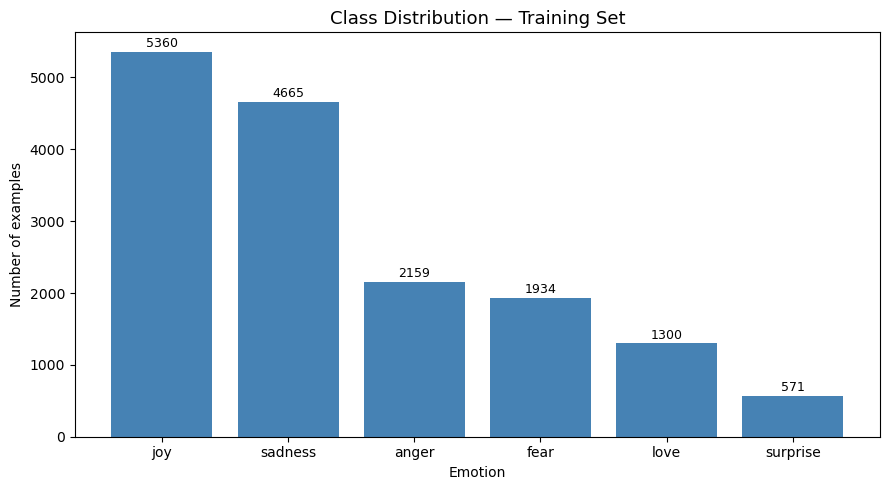

Imbalance ratio (largest / smallest): 9.4 : 1


In [4]:
counts = train['label'].value_counts()

plt.figure(figsize=(9, 5))
bars = plt.bar(counts.index, counts.values, color='steelblue')
plt.title('Class Distribution — Training Set', fontsize=13)
plt.xlabel('Emotion')
plt.ylabel('Number of examples')

for bar, value in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width() / 2, value + 60,
             str(value), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print(f"Imbalance ratio (largest / smallest): {counts.max() / counts.min():.1f} : 1")

### Observations and Choice of Evaluation Metric

The training set is strongly imbalanced: *joy* has roughly 9 times as many examples
as *surprise*. This has a direct consequence for how the model should be evaluated.

**Accuracy is misleading here.** A trivial model that always predicts *joy* would reach
about 34% accuracy without learning anything, and a model that simply ignores the two
smallest classes could still score well overall. Accuracy is dominated by the large classes.

**Macro-averaged F1** computes the F1 score separately for each of the six classes and
then averages them, giving every class equal weight regardless of its size. A model that
performs poorly on *surprise* is penalised just as much as one that performs poorly on
*joy*. This matches the assignment's requirement for multi-class problems, and it is the
metric used throughout this notebook.

This imbalance also motivates two later choices: treating the class prior as a tunable
hyperparameter, and experimenting with resampling techniques as an extension.